# Clustered Standard Errors — when a 'significant' predictor is pure noise 🧷
### Why firms in the same month aren't independent, and how a shared shock fakes a *t*-stat out of nothing

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Does_dependence_fake_significance%3F: Confirmed](https://img.shields.io/badge/Does_dependence_fake_significance%3F-Confirmed-8b949e?style=flat-square)

Here is a trap that has fooled a *lot* of published finance research. You have a panel: hundreds of firms, dozens of months, one candidate predictor `x`. You pool every firm-month into one big regression of returns `y` on `x`, and out pops a *t*-statistic of 3. Publishable! Except `x` is **pure noise** — it has *zero* true relationship with `y`. What went wrong?

The answer is **cross-sectional dependence**: in any given month, a common shock (the market, a macro surprise) moves *every* firm together, so your thousands of observations are nowhere near independent. The pooled regression doesn't know that, counts them as independent, and hands you a standard error that is far too small — and a *t*-stat far too big.

> 📓 **This is the plain-language layer.** Want the four standard errors, the Moulton inflation formula and the Monte-Carlo? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it, on a deterministic synthetic panel. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from clustered_se import data, strategy as st

# The whole demo runs on the deterministic, offline seed-840 null panel (common time effect,
# TRUE slope = 0). This is a synthetic-only method demo — there is no real-tape cell by design.
# Live cells use a reduced-rep panel so execution is quick; the frozen R dict below carries the
# full 2,000-rep headline (docs/results.md). LIVE = fast reduced run; R = frozen headline.
LIVE_REPS, LIVE_T, LIVE_N = 600, 50, 50

R_SWEEP = [(0.0, 0.046, 0.051, 0.057, 0.053, 0.997, 1.0), (0.2, 0.435, 0.464, 0.074, 0.053, 2.525, 2.429), (0.4, 0.559, 0.605, 0.073, 0.053, 3.415, 3.286), (0.6, 0.639, 0.695, 0.075, 0.053, 4.125, 3.962), (0.8, 0.679, 0.75, 0.081, 0.053, 4.744, 4.539)]
R_SWEEPN = [(2, 0.085, 0.398, 0.068, 0.025, 1.14, 1.118), (5, 0.158, 0.291, 0.059, 0.059, 1.376, 1.414), (10, 0.279, 0.387, 0.073, 0.06, 1.847, 1.803), (25, 0.464, 0.542, 0.078, 0.045, 2.675, 2.646), (50, 0.604, 0.661, 0.073, 0.053, 3.785, 3.64), (100, 0.696, 0.733, 0.065, 0.051, 5.1, 5.074)]


## The answer first 🎯

| Question | Answer |
|---|---|
| On a *noise* predictor (true effect **zero**), how often does the naive pooled *t* cry 'significant'? | **60% of the time** — twelve times the 5% it advertises. |
| Does clustering by *firm* fix it? | **No — it's worse (66%).** The dependence is *across firms in a month*, not within a firm over time; firm-clustering catches the wrong thing. |
| Does **Fama-MacBeth** fix it? | **Yes.** Its false-positive rate is **5.3%** — right at nominal. |
| Is the naive result real? | **No.** By construction there is *nothing there*; the *t*-stat is a standard-error illusion. |

> A pooled *t* > 2 from a cross-sectional regression, without the right clustering, is nearly worthless — exactly the way a suspiciously smooth track record is.

## 1 · The claim

> *"Regress returns on a predictor across a big firm-month panel; a *t*-stat above 2 means the predictor works."*

Petersen (2009) showed this is often false, because two kinds of correlation lurk in panel residuals: a **firm effect** (a firm is correlated with its own past) and a **time effect** (all firms move together in a given period). This study is about the **time effect** — the common shock — and how badly it fools the ordinary standard error.

## 2 · So what?

Because a huge fraction of the asset-pricing 'factor zoo' rests on exactly this kind of panel regression. If a shared monthly shock can manufacture a *t* of 3 from a predictor with **no** real content, then a naked *t*-stat proves nothing. The desk has shown the same lie told two other ways — by *trying many hypotheses* ([346 multiple-testing](../../346-multiple-testing/)) and by *autocorrelation over time* in a single series ([838 hac-necessity](../../838-hac-necessity/)). This is the **cross-sectional** version.

## 3 · How would we even know?

We build a panel we *know* is empty, so any 'significance' must be fake. Each period we draw one **shared** shock for the predictor and one **shared** shock for the outcome (they are drawn *independently*, so `x` truly says nothing about `y`), and add firm-specific noise on top. Set the true slope to **zero**. Then we do the pooled regression 600 times and count how often each method's *t*-stat clears 2.

If a method rejects far more than 5% of the time on this empty panel, its standard error is broken.

## 4 · The teardown — let's actually run it

Four ways to put a standard error on the *same* pooled slope: **naive** (pretend independence), **cluster by firm**, **cluster by time**, and **Fama-MacBeth** (a separate cross-sectional regression each period, then average). Watch which ones cry wolf.

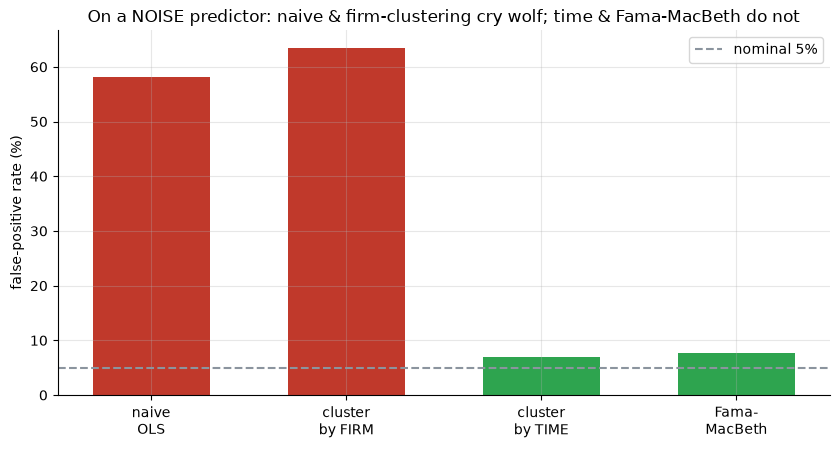

naive OLS      false-positive rate  58.2%  (SE is 0.27x the truth)
firm cluster   false-positive rate  63.5%  (SE is 0.24x the truth)
time cluster   false-positive rate   7.0%  (SE is 0.96x the truth)
Fama-MacBeth   false-positive rate   7.7%  (SE is 0.94x the truth)


In [2]:
X, Y = data.panel(LIVE_REPS, LIVE_T, LIVE_N, rho_x=0.5, rho_e=0.5, beta=0.0, seed=840)
c = st.calibration(X, Y, crit=1.96)
labels = ['naive\nOLS', 'cluster\nby FIRM', 'cluster\nby TIME', 'Fama-\nMacBeth']
keys = ['ols', 'firm', 'time', 'fm']
fp = [c[k+'_fp'] for k in keys]
colors = [RED, RED, GREEN, GREEN]
fig, ax = plt.subplots(figsize=(8.5, 4.6))
ax.bar(labels, [x*100 for x in fp], color=colors, width=.6)
ax.axhline(5, ls='--', c=GREY, lw=1.5, label='nominal 5%')
ax.set_ylabel('false-positive rate (%)')
ax.set_title('On a NOISE predictor: naive & firm-clustering cry wolf; time & Fama-MacBeth do not')
ax.legend(); plt.tight_layout(); plt.show()
for lab, k in zip(['naive OLS','firm cluster','time cluster','Fama-MacBeth'], keys):
    print(f'{lab:14s} false-positive rate {c[k+"_fp"]*100:5.1f}%  (SE is {c[k+"_se_ratio"]:.2f}x the truth)')

There it is. The **naive** pooled *t* fires on ~60% of empty panels, and clustering by **firm** is no better (~66%) — it's guarding the wrong door. Cluster by **time**, or use **Fama-MacBeth**, and the false-positive rate drops back to ~5%. The naive standard error is only about a **quarter** the size of the estimate's real swing — so of course the *t*-stat looks huge.

**How bad does it get?** The more of each period's variation comes from the shared shock (higher ρ), and the more firms per period (bigger N), the worse the naive test — while Fama-MacBeth stays flat at 5%:

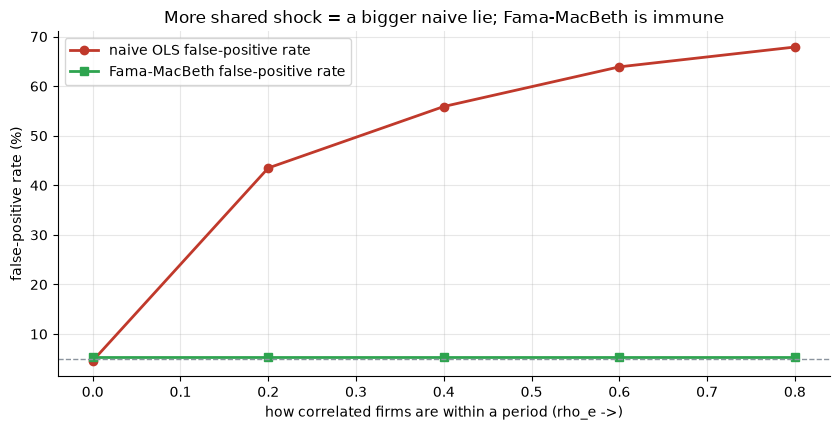

rho_e 0.0: naive   4.6%   Fama-MacBeth  5.3%
rho_e 0.2: naive  43.5%   Fama-MacBeth  5.3%
rho_e 0.4: naive  55.9%   Fama-MacBeth  5.3%
rho_e 0.6: naive  63.9%   Fama-MacBeth  5.3%
rho_e 0.8: naive  67.9%   Fama-MacBeth  5.3%


In [3]:
sweep = R_SWEEP  # frozen full-run rho_e sweep (docs/results.md)
rho = [s[0] for s in sweep]; ols = [s[1]*100 for s in sweep]; fm = [s[4]*100 for s in sweep]
fig, ax = plt.subplots(figsize=(8.5, 4.4))
ax.plot(rho, ols, 'o-', c=RED, lw=2, label='naive OLS false-positive rate')
ax.plot(rho, fm, 's-', c=GREEN, lw=2, label='Fama-MacBeth false-positive rate')
ax.axhline(5, ls='--', c=GREY, lw=1)
ax.set_xlabel('how correlated firms are within a period (rho_e ->)')
ax.set_ylabel('false-positive rate (%)')
ax.set_title('More shared shock = a bigger naive lie; Fama-MacBeth is immune')
ax.legend(); plt.tight_layout(); plt.show()
for s in sweep:
    print(f'rho_e {s[0]:.1f}: naive {s[1]*100:5.1f}%   Fama-MacBeth {s[4]*100:4.1f}%')

At a realistic ρ = 0.5 with 50 firms a month, the naive test is wrong ~60% of the time. This is exactly why cross-sectional asset-pricing studies report **Fama-MacBeth** *t*-stats, not pooled OLS ones.

## 5 · The verdict

- **Signal — None.** The panel has a true slope of zero — there is nothing to find. Fama-MacBeth agrees (5% rejection).
- **Tradability — Mirage.** You can't trade a standard-error artefact; costed, the null loses money.
- **Does cross-sectional dependence fake significance? — Confirmed.** Yes — the naive *t* cries wolf 60% of the time, and clustering on the wrong dimension makes it worse. Only time-clustering / Fama-MacBeth tell the truth.

## 6 · Could you actually 'trade' it?

No. There is no predictor here — `x` is noise. If you built the dollar-neutral long-short the naive *t*-stat tempts you into, its gross return is indistinguishable from zero, and once you pay to trade it every period it bleeds ~25%/yr. A broken standard error is not a strategy.

## 7 · Going further 🚪

- **The two cousins.** [838 HAC Necessity](../../838-hac-necessity/) is the same disease along the *time* axis (a single serially-correlated series, fixed by Newey-West); [346 multiple-testing](../../346-multiple-testing/) is the *how-many-hypotheses* haircut. This study is the *cross-sectional* axis.
- **The fix is standard.** Fama-MacBeth (1973) and two-way clustering (Cameron-Gelbach-Miller 2011) — see the quants notebook for the mechanics.

*Think your panel regression's *t* > 2 is real? Fork this, drop in your own predictor, and compare the naive *t* to the Fama-MacBeth one — the gap is the lie.*